# Price-Intent Backtest

Test a dynamic long/short trade plan for any Yahoo Finance ticker. Set the ticker, rolling-price rules, sizing, costs, and risk limits in **Block 1**, then run all cells.

The notebook downloads daily OHLCV data, caches it under `cache/price_history/`, checks current index membership using the same cached constituent workflow as `03_index_search.ipynb`, and compares the strategy with buy-and-hold and the selected index.

> This is a daily-bar research backtest, not an execution simulator or financial advice. If both the target and stop are touched during one daily candle, the default assumption is that the stop happened first.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from backtesting import (
    build_dynamic_price_levels,
    export_backtest_results,
    load_backtest_market_data,
    plot_backtest_results,
    prepare_backtest_results,
    prepare_trade_details,
    run_price_intent_backtest,
)

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:,.2f}".format

## Block 1: Inputs

Entry, target, fixed-stop, and trailing-stop levels are recalculated for every session using only earlier price history. `end_date` is inclusive. Supported index names are `dow30`, `nasdaq100`, `sp500`, `ftse100`, and `ftse250`; a Yahoo benchmark symbol such as `^GSPC` also works, but membership checking is then skipped.

In [2]:
# Instrument and historical window
ticker = "AAPL"
index_name = "sp500"
start_date = "2025-01-01"
end_date = None  # Inclusive; use None for the latest available day

# Dynamic price and risk rules
price_lookback_days = 20       # Prior-session low/high channel
atr_window_days = 14           # Prior-session volatility window
stop_loss_atr_multiplier = 2.0
trailing_stop_atr_multiplier = 3.0
allow_short_selling = False    # True enables mirrored short trades

# Capital, position, and order limits
initial_capital = 100.00
position_size_pct = 1.00       # Fraction of available cash used per entry
max_shares = None              # Example: 50; None means no share cap
whole_shares = False           # False allows fractional shares
max_entries = 1000             # Maximum completed/attempted entries
allow_reentry = True
cooldown_days = 5              # Trading sessions after an exit
min_holding_days = 30          # Minimum trading sessions before a normal exit
max_holding_days = None        # Example: 60; exits at close after this many sessions

# Execution assumptions
commission_per_order = 0.00
slippage_bps = 0.0             # 10 bps = 0.10%
same_day_exit_priority = "stop"  # "stop" (conservative) or "target"
force_exit_at_end = False

# Cache and optional exports
cache_dir = "cache"
cache_max_age_hours = 24
refresh_price_cache = True
check_index_membership = True
export_results = False
save_chart = False

## Block 2: Cached market data

The cache follows the project's existing pattern: local files, configurable expiry, refresh on expiry, and metadata showing whether the cache was used. If a refresh fails but a stale price cache exists, the notebook uses that stale copy and warns.

In [3]:
market_data = load_backtest_market_data(
    ticker=ticker,
    index_name=index_name,
    start_date=start_date,
    end_date=end_date,
    cache_dir=cache_dir,
    cache_max_age_hours=cache_max_age_hours,
    refresh_price_cache=refresh_price_cache,
    check_index_membership=check_index_membership,
)

benchmark_ticker = market_data["benchmark_ticker"]
price_history = market_data["price_history"]
benchmark_history = market_data["benchmark_history"]

dynamic_levels = build_dynamic_price_levels(
    history=price_history,
    lookback_days=price_lookback_days,
    atr_window_days=atr_window_days,
    stop_atr_multiplier=stop_loss_atr_multiplier,
    trailing_atr_multiplier=trailing_stop_atr_multiplier,
)
buy_price = dynamic_levels["buy_price"]
sell_price = dynamic_levels["sell_price"]
stop_loss = dynamic_levels["stop_loss"]
short_stop_loss = dynamic_levels["short_stop_loss"]
trailing_stop_pct = dynamic_levels["trailing_stop_pct"]

display(pd.DataFrame([
    market_data["ticker_cache_meta"],
    market_data["benchmark_cache_meta"],
]))
display(pd.DataFrame([market_data["membership"]]))
display(dynamic_levels.dropna().tail())
print(market_data["load_message"])

,symbol,rows,cache_used,stale_fallback,cache_age_hours,cache_file
0,AAPL,405,False,False,0.00,cache\price_history\AAPL_20250101_20260816_1d.csv
1,^GSPC,405,False,False,0.00,cache\price_history\GSPC_20250101_20260816_1d.csv


,index_name,ticker,is_current_constituent,constituents_loaded,cache_used,cache_file,note
0,sp500,AAPL,True,503,True,cache\sp500_tickers.json,Current membership only; this is not a histori...


,Date,buy_price,sell_price,stop_loss,short_stop_loss,trailing_stop_pct,atr
400,2026-08-10,300.00,344.57,281.30,363.27,0.09,9.35
401,2026-08-11,300.00,344.57,281.10,363.47,0.09,9.45
402,2026-08-12,300.00,344.57,280.89,363.68,0.09,9.56
403,2026-08-13,300.00,344.57,281.09,363.48,0.09,9.45
404,2026-08-14,300.00,344.57,282.35,362.22,0.09,8.82


Loaded 405 AAPL sessions and 405 ^GSPC sessions from 2025-01-02 to 2026-08-14.


## Block 3: Backtest engine

Execution rules:

- The long entry and target are the prior rolling low and high. ATR sets the fixed and trailing risk levels.
- Every dynamic level is shifted by one session so today's high/low never sets today's order.
- A long limit fills when `Low <= buy_price`; a gap below the limit fills at the opening price.
- When short selling is enabled, the upper channel opens a short and the lower channel is its cover target.
- A target or stop can first execute on the session after entry, avoiding unknowable intraday ordering on the entry candle.
- A gap through a target or stop fills at the opening price before slippage.
- If target and stop are both touched in one later candle, `same_day_exit_priority` decides the result.
- Trailing stops use completed-session highs for longs and lows for shorts.
- Open positions are marked to each close and optionally liquidated on the final session.

In [4]:
backtest = run_price_intent_backtest(
    history=price_history,
    benchmark=benchmark_history,
    entry_limit=buy_price,
    target=sell_price,
    fixed_stop=stop_loss,
    capital=initial_capital,
    size_pct=position_size_pct,
    share_limit=max_shares,
    use_whole_shares=whole_shares,
    entries_limit=max_entries,
    reentry=allow_reentry,
    wait_days=cooldown_days,
    minimum_holding_days=min_holding_days,
    holding_limit=max_holding_days,
    trailing_pct=trailing_stop_pct,
    fee=commission_per_order,
    slip_bps=slippage_bps,
    priority=same_day_exit_priority,
    liquidate_at_end=force_exit_at_end,
    allow_short=allow_short_selling,
    short_entry_limit=sell_price,
    short_target=buy_price,
    short_fixed_stop=short_stop_loss,
)

## Block 4: Results

The summary separates strategy return from passive ticker return and benchmark return. The order log shows every fill; the round-trip table shows one row per completed trade.

In [5]:
results = prepare_backtest_results(backtest)
summary = results["summary"]
transactions = results["transactions"]
round_trips = results["round_trips"]
equity_curve = results["equity_curve"]

display(results["summary_display"])
display(results["transactions_display"])
display(results["round_trips_display"])

if export_results:
    exported_files = export_backtest_results(backtest, ticker, start_date)
    export_directory = next(iter(exported_files.values())).parent.resolve()
    print(f"Exported CSV files to {export_directory}")

,value
start_date,2025-01-02 00:00:00
end_date,2026-08-14 00:00:00
initial_capital,100.00
ending_equity,130.07
strategy_return_pct,30.07
annualized_return_pct,17.71
buy_hold_return_pct,25.46
benchmark_return_pct,32.67
excess_vs_buy_hold_pct_points,4.61
excess_vs_benchmark_pct_points,-2.60


,Date,action,side,reason,raw_price,fill_price,shares,gross_value,commission,cash_after,realized_pnl,entry_number
0,2025-03-10,BUY,LONG,BUY_LIMIT,227.20,227.20,0.44,100.00,0.00,0.00,NaN,1
1,2025-05-01,SELL,LONG,TRAILING_STOP,209.08,209.08,0.44,92.02,0.00,92.02,-7.98,1
2,2025-07-31,BUY,LONG,BUY_LIMIT,207.22,207.22,0.44,92.02,0.00,0.00,NaN,2
3,2025-09-19,SELL,LONG,TARGET,241.32,241.32,0.44,107.17,0.00,107.17,15.14,2
4,2026-01-05,BUY,LONG,BUY_LIMIT,266.95,266.95,0.40,107.17,0.00,0.00,NaN,3
5,2026-03-05,SELL,LONG,TRAILING_STOP,258.22,258.22,0.40,103.66,0.00,103.66,-3.51,3
6,2026-03-13,BUY,LONG,BUY_LIMIT,253.68,253.68,0.41,103.66,0.00,0.00,NaN,4
7,2026-04-30,SELL,LONG,TARGET,275.77,275.77,0.41,112.69,0.00,112.69,9.03,4
8,2026-06-09,BUY,LONG,BUY_LIMIT,290.23,290.23,0.39,112.69,0.00,0.00,NaN,5
9,2026-07-27,SELL,LONG,TARGET,334.99,334.99,0.39,130.07,0.00,130.07,17.38,5


,entry_number,side,entry_date,exit_date,entry_price,exit_price,shares,exit_reason,holding_sessions,pnl,return_pct
0,1,LONG,2025-03-10,2025-05-01,227.20,209.08,0.44,TRAILING_STOP,37,-7.98,-7.98
1,2,LONG,2025-07-31,2025-09-19,207.22,241.32,0.44,TARGET,35,15.14,16.46
2,3,LONG,2026-01-05,2026-03-05,266.95,258.22,0.40,TRAILING_STOP,41,-3.51,-3.27
3,4,LONG,2026-03-13,2026-04-30,253.68,275.77,0.41,TARGET,33,9.03,8.71
4,5,LONG,2026-06-09,2026-07-27,290.23,334.99,0.39,TARGET,32,17.38,15.42


## Block 5: Price, benchmark, and performance chart

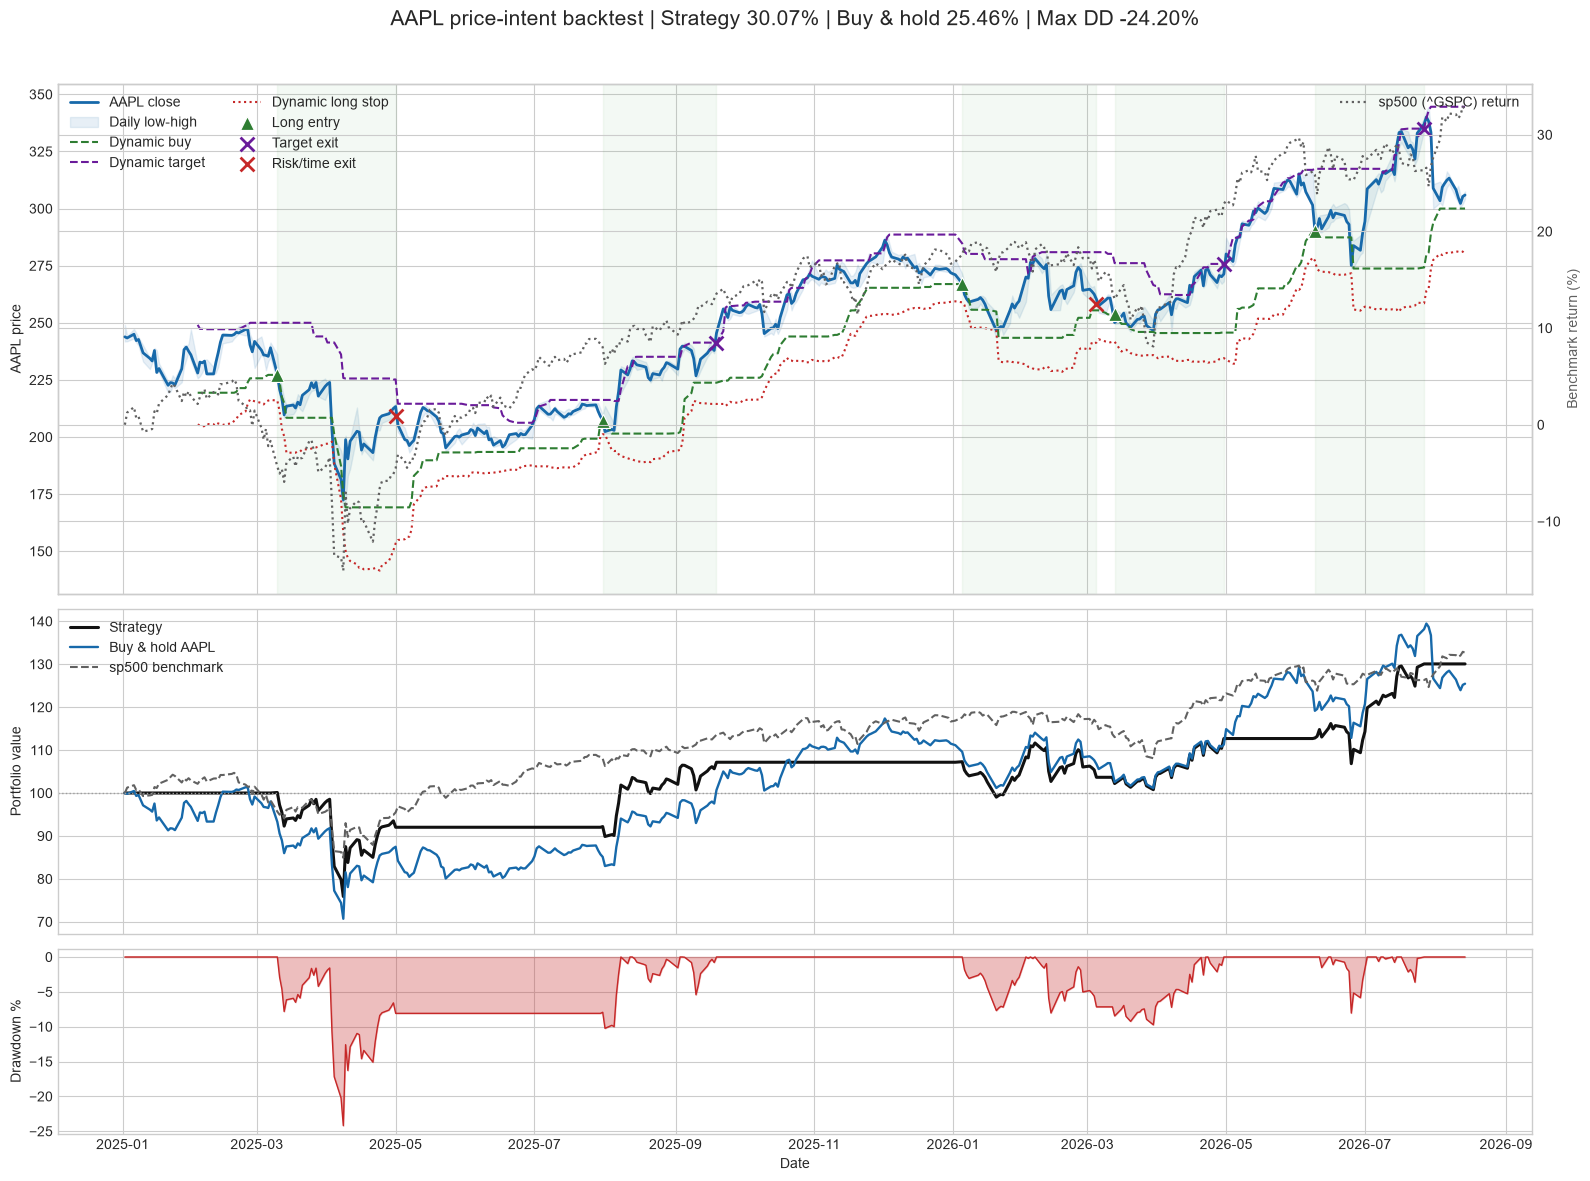

In [6]:
fig, chart_file = plot_backtest_results(
    backtest=backtest,
    benchmark_history=benchmark_history,
    ticker=ticker,
    index_name=index_name,
    benchmark_ticker=benchmark_ticker,
    buy_price=buy_price,
    sell_price=sell_price,
    stop_loss=stop_loss,
    initial_capital=initial_capital,
    chart_output_dir="output" if save_chart else None,
)
if chart_file is not None:
    print(f"Saved chart to {chart_file.resolve()}")

plt.show()

## Block 6: Simulated trade execution details

One row per simulated trade, including the filled entry and exit, quantity, notional, fees, entry-time target and risk levels, holding period, and realized result. These are historical backtest fills for research—not live orders or a recommendation to trade.

In [7]:
trade_details = prepare_trade_details(backtest, ticker=ticker)

if trade_details.empty:
    display(pd.DataFrame({"message": ["No simulated trade entries were executed."]}))
else:
    display(trade_details)

if export_results:
    print(f"Trade-detail CSV: {exported_files['trade_details'].resolve()}")

,trade_number,ticker,side,status,buy_date,buy_price,sell_date,sell_price,entry_action,entry_date,...,exit_action,exit_date,exit_price,exit_notional,exit_commission,cash_after_exit,exit_reason,holding_sessions,realized_pnl,return_pct
0,1,AAPL,LONG,CLOSED,2025-03-10,227.20,2025-05-01,209.08,BUY,2025-03-10,...,SELL,2025-05-01,209.08,92.02,0.00,92.02,TRAILING_STOP,37,-7.98,-7.98
1,2,AAPL,LONG,CLOSED,2025-07-31,207.22,2025-09-19,241.32,BUY,2025-07-31,...,SELL,2025-09-19,241.32,107.17,0.00,107.17,TARGET,35,15.14,16.46
2,3,AAPL,LONG,CLOSED,2026-01-05,266.95,2026-03-05,258.22,BUY,2026-01-05,...,SELL,2026-03-05,258.22,103.66,0.00,103.66,TRAILING_STOP,41,-3.51,-3.27
3,4,AAPL,LONG,CLOSED,2026-03-13,253.68,2026-04-30,275.77,BUY,2026-03-13,...,SELL,2026-04-30,275.77,112.69,0.00,112.69,TARGET,33,9.03,8.71
4,5,AAPL,LONG,CLOSED,2026-06-09,290.23,2026-07-27,334.99,BUY,2026-06-09,...,SELL,2026-07-27,334.99,130.07,0.00,130.07,TARGET,32,17.38,15.42
